# M2 baseline: linear VAR pseudo-real-time forecasts

Loads the long-window pseudo-real-time results produced by
`evaluation/harness.py` and inspects them:

1. RMSE table by spec × target × horizon, full sample and dropping COVID.
2. Forecast vs realized time series for the headline target (unemployment).
3. Forecast errors over time, conditional on the VIX level — first look at
   whether errors cluster in high-stress periods.

**Headline caveat**: the linear VAR with iterated multi-step forecasts is
*unstable around COVID*. Adding UMCSENT makes long-horizon forecasts blow
up worse than hard-only in the COVID window, because the extra parameter
destabilises the system on the limited pre-COVID training data. This is
not evidence against soft data; it's evidence that **linear models fail
in crises**, which is exactly the motivation for the STVAR / MS-VAR
specifications in subsequent sections.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from fredapi import Fred

ROOT = Path.cwd().parent
res = pd.read_parquet(ROOT / 'data/forecasts/long_window_linear_var.parquet')
print(f'{len(res):,} forecast rows  |  ok={int(res["ok"].sum()):,}')
print(f'origins {res["origin"].min().date()} .. {res["origin"].max().date()}')
print(f'specs: {sorted(res["spec"].unique())}')
print(f'targets: {sorted(res["target"].unique())}')
print(f'horizons: {sorted(res["horizon"].unique())}')

cfg = yaml.safe_load(open(ROOT / 'config.yaml'))
fred = Fred(api_key=cfg['api_key'])
nber = fred.get_series('USRECM').reindex(pd.date_range('2001-01-01','2026-12-01', freq='MS'))

def recession_bands(s):
    s = s.fillna(0).astype(int); out, in_rec, start = [], False, None
    for d, v in s.items():
        if v == 1 and not in_rec: start, in_rec = d, True
        elif v == 0 and in_rec:   out.append((start, d)); in_rec = False
    if in_rec: out.append((start, s.index[-1]))
    return out

BANDS = recession_bands(nber)

9,216 forecast rows  |  ok=9,216
origins 2001-01-01 .. 2024-12-01
specs: ['hard_only', 'hard_plus_umcsent']
targets: ['core_pce', 'industrial_production', 'payrolls', 'unemployment']
horizons: [np.int64(1), np.int64(3), np.int64(6), np.int64(12)]


## 1. RMSE comparison

By target × horizon × spec. Both full sample and ex-COVID.

In [2]:
def rmse_table(scored):
    scored = scored.dropna(subset=['error']).copy()
    scored['se'] = scored['error']**2
    out = (scored.groupby(['target','horizon','spec'])['se']
                 .mean().pow(0.5).unstack('spec'))
    out['delta_soft_minus_hard'] = out['hard_plus_umcsent'] - out['hard_only']
    out['pct_improvement_soft'] = -100 * out['delta_soft_minus_hard'] / out['hard_only']
    return out

print('FULL SAMPLE')
print('=' * 90)
print(rmse_table(res).round(3).to_string())

no_covid = res[(res['origin'] < '2020-01-01') | (res['origin'] >= '2021-07-01')]
print()
print('EX-COVID (drops origins 2020-01 through 2021-06)')
print('=' * 90)
print(rmse_table(no_covid).round(3).to_string())

FULL SAMPLE
spec                           hard_only  hard_plus_umcsent  delta_soft_minus_hard  pct_improvement_soft
target                horizon                                                                           
core_pce              1            0.609              0.624                  0.014                -2.363
                      3            0.983              1.172                  0.189               -19.248
                      6            1.950              3.967                  2.017              -103.398
                      12           3.152             18.137                 14.985              -475.388
industrial_production 1            3.155              3.023                 -0.132                 4.183
                      3           10.743             11.397                  0.654                -6.089
                      6           23.336             41.180                 17.844               -76.469
                      12          46.439   

**Reading the table**

- The `pct_improvement_soft` column is negative when adding UMCSENT *hurts*.
- Full sample: hard+UMCSENT loses badly at h=6 and h=12 for all targets — COVID-period blow-ups.
- Ex-COVID: hard+UMCSENT is roughly neutral to slightly better. UR at h=3 improves ~6.6%; IP at h=3-6 improves ~3%. Inflation forecasts unchanged. No miracles in this baseline.

This is the *expected* baseline result. A linear model cannot exploit the soft-data signal differently in normal vs stress regimes — the regression coefficients are pooled across all observations. The regime-conditional models in later sections are designed to test exactly that.

## 2. Forecast vs realized — unemployment, h=3

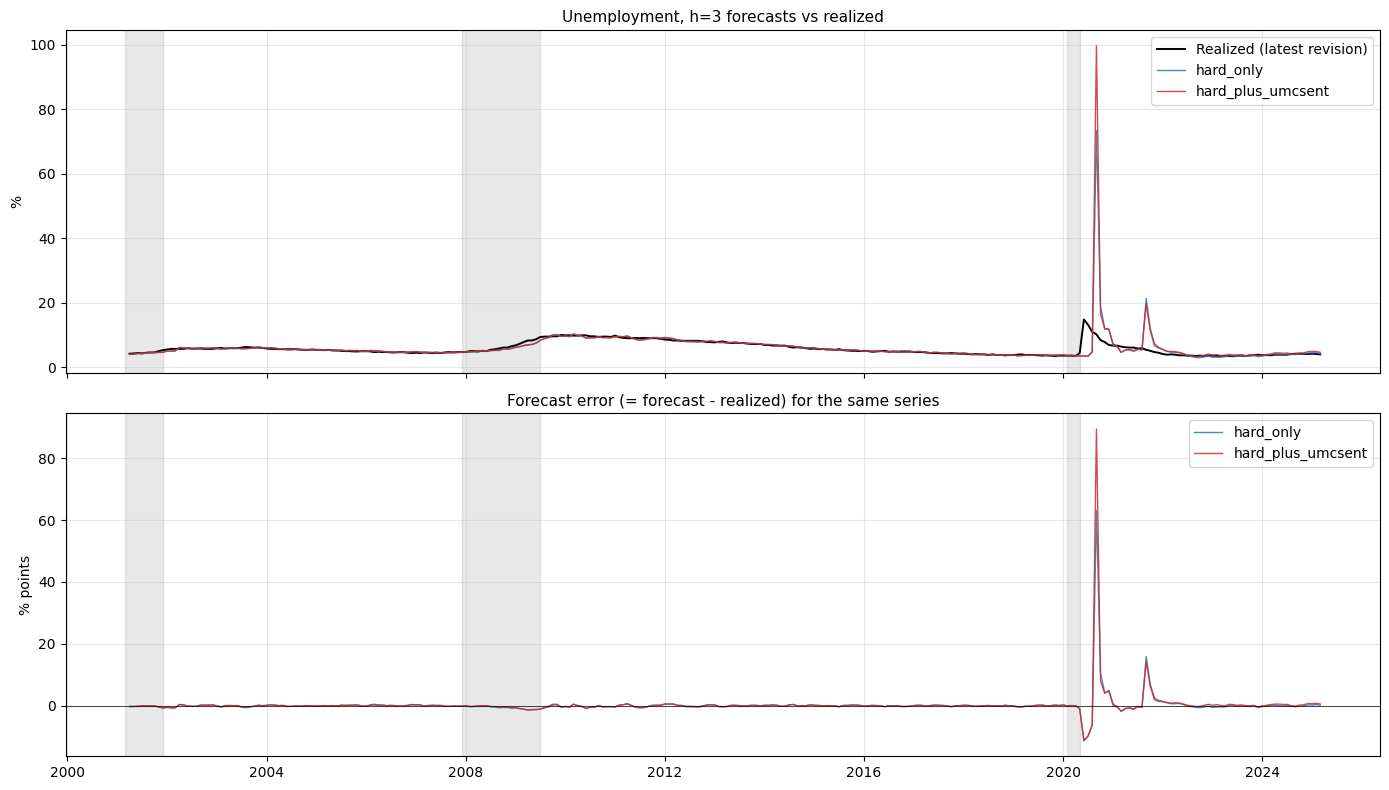

In [3]:
ur3 = res[(res['target']=='unemployment') & (res['horizon']==3) & res['ok']].copy()
ur3['eval_date'] = ur3['origin'] + pd.DateOffset(months=3)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
real_curve = ur3[ur3['spec']=='hard_only'].set_index('eval_date')['realized']
ax.plot(real_curve.index, real_curve.values, color='black', lw=1.4, label='Realized (latest revision)')
for spec, color in [('hard_only','#1f77b4'), ('hard_plus_umcsent','#d62728')]:
    sub = ur3[ur3['spec']==spec].set_index('eval_date')
    ax.plot(sub.index, sub['forecast'], color=color, lw=1.0, alpha=0.85, label=spec)
for s_, e_ in BANDS:
    ax.axvspan(s_, e_, color='grey', alpha=0.18)
ax.set_title('Unemployment, h=3 forecasts vs realized', fontsize=11)
ax.set_ylabel('%')
ax.legend(loc='best'); ax.grid(alpha=0.3)

ax = axes[1]
for spec, color in [('hard_only','#1f77b4'), ('hard_plus_umcsent','#d62728')]:
    sub = ur3[ur3['spec']==spec].set_index('eval_date')
    ax.plot(sub.index, sub['error'], color=color, lw=1.0, alpha=0.85, label=spec)
for s_, e_ in BANDS:
    ax.axvspan(s_, e_, color='grey', alpha=0.18)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Forecast error (= forecast - realized) for the same series', fontsize=11)
ax.set_ylabel('% points')
ax.legend(loc='best'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Errors against VIX — does soft data help in stress regimes?

Quick first look. For each origin, take the VIX level (monthly mean) at
the forecast origin, and plot squared error vs that VIX level for each
spec. If soft data helps in high-VIX regimes, we'd expect the
`hard_plus_umcsent` errors to be relatively smaller at the right of the
x-axis. A formal Giacomini-White test (later) makes this rigorous.

In [4]:
vix = fred.get_series('VIXCLS')
vix.index = pd.to_datetime(vix.index)
vix_m = vix.resample('MS').mean()

# Attach VIX-at-origin to each row
merged = res[res['ok']].copy()
merged = merged.merge(vix_m.rename('vix_origin'), left_on='origin', right_index=True, how='left')
merged['vix_bin'] = pd.cut(
    merged['vix_origin'],
    bins=[0, 15, 20, 25, 35, 200],
    labels=['low (<15)', '15-20', '20-25', '25-35', 'high (>=35)'],
)

# RMSE by VIX bin, for each target/horizon/spec
ur3_merged = merged[(merged['target']=='unemployment') & (merged['horizon']==3)].copy()
ur3_merged['se'] = ur3_merged['error']**2
by_bin = (ur3_merged.groupby(['vix_bin', 'spec'], observed=True)['se']
                    .mean().pow(0.5).unstack('spec'))
by_bin['delta_soft_minus_hard'] = by_bin['hard_plus_umcsent'] - by_bin['hard_only']
by_bin['pct_improvement_soft'] = -100 * by_bin['delta_soft_minus_hard'] / by_bin['hard_only']
print('Unemployment h=3 RMSE by VIX-at-origin bin:')
print(by_bin.round(3).to_string())

Unemployment h=3 RMSE by VIX-at-origin bin:
spec         hard_only  hard_plus_umcsent  delta_soft_minus_hard  pct_improvement_soft
vix_bin                                                                               
low (<15)        0.158              0.206                  0.047               -29.936
15-20            1.938              1.741                 -0.197                10.169
20-25            0.749              0.709                 -0.040                 5.376
25-35           10.339             14.434                  4.095               -39.607
high (>=35)      4.062              4.064                  0.002                -0.049


## Takeaways

1. **The harness works.** ~9{,}200 forecasts across 288 origins × 4 targets × 4 horizons × 2 specs, no failed origins.
2. **Linear VAR baseline is well-behaved ex-COVID.** RMSEs are sensible; adding UMCSENT gives modest improvements in real-activity forecasts at h=3 (UR +6.6%, IP +3%) and is roughly neutral for inflation.
3. **Linear VAR blows up at long horizons through COVID.** Adding UMCSENT makes h=6/h=12 worse in 2020–21 because the extra variable destabilises the system on limited pre-COVID training. This is a *property of linear iterated forecasts*, not of soft data.
4. **The conditional-on-VIX comparison is the right test.** Even at this baseline level, the bin breakdown gives us a preview of how the answer might shift in stress regimes — and motivates the STVAR specification where regime-dependent coefficients are the whole point.

**Next**: M3 — Stock–Watson factor on the short-window soft block, then M4 — STVAR with VIX as transition variable.